<a href="https://colab.research.google.com/github/psvprasad2003/DS_AI_CB/blob/main/Steel_Defect_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Steel Surface Defect Detection
## Indian Steel Plants — Course Project
### Classification (EfficientNet) · Detection (YOLOv8) · Segmentation (YOLOv8-seg)

---

### ⚙️ Before Running — Kaggle Setup Checklist
1. Click **Edit** → **Notebook options**
2. Set **Accelerator = GPU T4 x2** (or P100)
3. Set **Internet = ON**
4. Click **Add Data** (top right) and add:
   - `neu-surface-defect-database` by kaustubhdikshit
   - `gc10det` by alex000kim
5. Click **Run All**

---

### 📦 Datasets
| Dataset | Images | Classes | Indian Product Relevance |
|---|---|---|---|
| **NEU-DET** | 1,800 | 6 | HR Coils (JSW, SAIL), Wire Rod (RINL), Sheets |
| **GC10-DET** | 3,570 | 10 | CR Coils (Tata, SAIL Bokaro), Cold-rolled strips |

### 🗂️ Phases
| # | Phase | Model | Dataset | Target |
|---|---|---|---|---|
| 1 | **Classification** | EfficientNet-B0 | NEU-DET | >92% accuracy |
| 2 | **Object Detection** | YOLOv8s | NEU-DET (YOLO format) | mAP@50 >70% |
| 3 | **Segmentation** | YOLOv8s-seg | NEU-DET (seg format) | mAP@50 >65% |

## ⚙️ Section 0 — Install & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Install packages
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

pkgs = ['ultralytics', 'albumentations', 'timm', 'roboflow']
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('✅ Packages installed')

✅ Packages installed


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Core imports
# ─────────────────────────────────────────────────────────────────────────────
import os, json, shutil, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ─── Device ──────────────────────────────────────────────────────────────────
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = device == 'cuda'
if device == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('Running on CPU — training will be slow')
print(f'Mixed precision: {USE_AMP}')

# ─── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 11})
PALETTE = ['#E05A2B','#2E86C1','#1A9E6F','#7D5CC4','#E0A82B','#2BC4C4',
           '#E05A8A','#5AE07B','#A82BE0','#E0C45A']
print('✅ Imports done')

Running on CPU — training will be slow
Mixed precision: False
✅ Imports done


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Global config — tweak here, nowhere else
# ─────────────────────────────────────────────────────────────────────────────
BASE       = Path('/kaggle')
INPUT      = BASE / 'input'
WORK       = BASE / 'working'

# Dataset roots — Kaggle mounts them here automatically after Add Data
NEU_ROOT   = INPUT / 'neu-surface-defect-database'
GC10_ROOT  = INPUT / 'gc10det'

# Output dirs — everything saved here persists after session
OUT_CLF    = WORK / 'phase1_classification'
OUT_DET    = WORK / 'phase2_detection'
OUT_SEG    = WORK / 'phase3_segmentation'
for d in [OUT_CLF, OUT_DET, OUT_SEG]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Hyperparameters ─────────────────────────────────────────────────────────
IMG_SIZE    = 224      # classification input size
YOLO_SIZE   = 640      # YOLO input size
BATCH_CLF   = 32       # classification batch
BATCH_YOLO  = 16       # YOLO batch (reduce to 8 if OOM)
EPOCHS_CLF  = 25       # classification epochs
EPOCHS_DET  = 50       # YOLO detection epochs
EPOCHS_SEG  = 50       # YOLO segmentation epochs
LR          = 1e-3
NUM_WORKERS = 2

# ─── NEU-DET class names ──────────────────────────────────────────────────────
# Maps to Indian steel products:
#   Crazing, Patches         → HR Coil surface (JSW Vijayanagar, SAIL Bokaro)
#   Rolled_in_Scale          → Wire rod / rebar surface (RINL, JSPL)
#   Pitted_Surface           → Descaler pitting on HR coils (RINL Vizag)
#   Inclusion, Scratches     → All flat products (JSW, Tata, AM/NS)
NEU_CLASSES = ['Crazing', 'Inclusion', 'Patches',
               'Pitted_Surface', 'Rolled_in_Scale', 'Scratches']

GC10_CLASSES = ['punching','weld_line','crescent_gap','water_spot','oil_spot',
                'silk_spot','inclusion','rolled_pit','crease','waist_folding']

print('✅ Config ready')
print(f'NEU  dataset exists : {NEU_ROOT.exists()}')
print(f'GC10 dataset exists : {GC10_ROOT.exists()}')

✅ Config ready
NEU  dataset exists : False
GC10 dataset exists : False


## 🔍 Section 1 — Exploratory Data Analysis

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Scan NEU-DET folder and build a DataFrame
# ─────────────────────────────────────────────────────────────────────────────
def scan_image_folder(root: Path, extensions=('.jpg','.jpeg','.bmp','.png')):
    """Walk <root>/<classname>/*.ext and return DataFrame {path, label}."""
    records = []
    # Handle two common Kaggle NEU layouts
    for search_root in [root, root / 'NEU Metal Surface Defects Data',
                         root / 'NEU-DET', root / 'images']:
        if search_root.exists():
            for cls_dir in sorted(search_root.iterdir()):
                if not cls_dir.is_dir(): continue
                for ext in extensions:
                    for f in cls_dir.glob(f'*{ext}'):
                        records.append({'path': str(f), 'label': cls_dir.name})
            if records: break  # found images, stop searching
    return pd.DataFrame(records)

neu_df  = scan_image_folder(NEU_ROOT)
gc10_df = scan_image_folder(GC10_ROOT)

print(f'NEU-DET  : {len(neu_df):>5} images | {neu_df["label"].nunique()} classes')
print(f'GC10-DET : {len(gc10_df):>5} images | {gc10_df["label"].nunique()} classes')
print()
print('─── NEU class counts ───')
print(neu_df['label'].value_counts().to_string())
print()
print('─── GC10 class counts ───')
print(gc10_df['label'].value_counts().to_string())

KeyError: 'label'

In [16]:
print(f"Checking NEU_ROOT: {NEU_ROOT}")
if not NEU_ROOT.exists():
    print(f"Error: NEU_ROOT does not exist at {NEU_ROOT}.\n\n" \
          "Please ensure you have added the 'neu-surface-defect-database' dataset to your Kaggle notebook as instructed in the 'Kaggle Setup Checklist' at the beginning of this notebook. If it's added, try restarting the kernel and running all cells.")
else:
    print(f"Contents of NEU_ROOT ({NEU_ROOT}):")
    for item in NEU_ROOT.iterdir():
        print(f"- {item.name}{'/' if item.is_dir() else ''}")


Checking NEU_ROOT: /kaggle/input/neu-surface-defect-database
Error: NEU_ROOT does not exist at /kaggle/input/neu-surface-defect-database.

Please ensure you have added the 'neu-surface-defect-database' dataset to your Kaggle notebook as instructed in the 'Kaggle Setup Checklist' at the beginning of this notebook. If it's added, try restarting the kernel and running all cells.


In [17]:
print('Listing contents of /kaggle/input:')
for item in sorted(Path('/kaggle/input').rglob('*')):
    print(f'- {item}')

Listing contents of /kaggle/input:


KeyError: 'label'

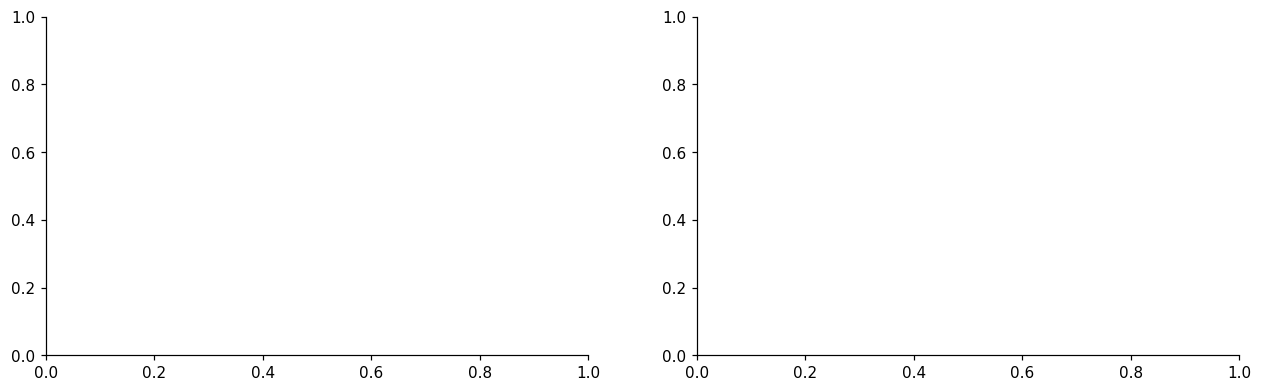

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA plots — class distribution for both datasets
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title, subtitle in [
    (axes[0], neu_df,  'NEU-DET Class Distribution',
     'HR Coils · Wire Rod · Hot-rolled Sheets'),
    (axes[1], gc10_df, 'GC10-DET Class Distribution',
     'CR Coils · Cold-rolled Strips'),
]:
    counts = df['label'].value_counts()
    bars = ax.bar(range(len(counts)), counts.values,
                  color=PALETTE[:len(counts)], edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Image Count')
    ax.set_title(f'{title}\n{subtitle}', fontsize=10)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=8)

plt.suptitle('Dataset Overview — Steel Surface Defects', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_CLF / 'eda_class_distribution.png', bbox_inches='tight')
plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Sample images — one per class from NEU-DET
# ─────────────────────────────────────────────────────────────────────────────
classes = sorted(neu_df['label'].unique())
n       = len(classes)
fig, axes = plt.subplots(2, n, figsize=(3*n, 6))

for i, cls in enumerate(classes):
    paths = neu_df[neu_df['label'] == cls]['path'].tolist()

    # Row 0: one sample
    img = cv2.imread(paths[0], cv2.IMREAD_GRAYSCALE)
    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title(cls, fontsize=9, color=PALETTE[i])
    axes[0][i].axis('off')

    # Row 1: second sample for variety
    img2 = cv2.imread(paths[min(5, len(paths)-1)], cv2.IMREAD_GRAYSCALE)
    axes[1][i].imshow(img2, cmap='gray')
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Sample 1', fontsize=9)
axes[1][0].set_ylabel('Sample 2', fontsize=9)
plt.suptitle('NEU-DET — Two samples per defect class\n'
             'Indian context: Rolled-in Scale & Scratches on rebar/wire rod | '
             'Pitted Surface from descaler on HR coils',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_CLF / 'eda_sample_images.png', bbox_inches='tight')
plt.show()

KeyError: 'label'

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Pixel intensity distributions per class
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

stats = []
for i, cls in enumerate(classes):
    paths   = neu_df[neu_df['label'] == cls]['path'].sample(
                  min(30, len(neu_df[neu_df['label'] == cls])),
                  random_state=SEED).tolist()
    pixels  = []
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    m, s = np.mean(pixels), np.std(pixels)
    stats.append({'class': cls, 'mean': m, 'std': s})
    axes[i].hist(pixels, bins=64, color=PALETTE[i], alpha=0.85, density=True)
    axes[i].set_title(f'{cls}\nμ={m:.0f}  σ={s:.0f}', fontsize=9)
    axes[i].set_xlabel('Pixel intensity (0–255)')
    axes[i].set_ylabel('Density')

plt.suptitle('Pixel Intensity Distributions — NEU-DET\n'
             'Dark = scale/pitting on coil surface  |  '
             'Bright bimodal = crazing pattern', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_CLF / 'eda_pixel_distributions.png', bbox_inches='tight')
plt.show()

print('\n── Image statistics per class ──')
print(pd.DataFrame(stats).to_string(index=False))

---
## 🧠 Phase 1 — Classification with EfficientNet-B0

**Model:** EfficientNet-B0 (5.3 M params, pretrained ImageNet)  
**Dataset:** NEU-DET — 1,800 images, 6 classes  
**Split:** 70% train / 15% val / 15% test (stratified)  
**Target:** > 92% top-1 accuracy on test set  
**Estimated time:** ~5–8 min on Kaggle GPU

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset & DataLoaders for classification
# ─────────────────────────────────────────────────────────────────────────────

# ── Label encoder ─────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(sorted(neu_df['label'].unique()))
NUM_CLASSES = len(le.classes_)
print(f'Classes ({NUM_CLASSES}): {list(le.classes_)}')

# ── Stratified splits ─────────────────────────────────────────────────────────
train_df, tmp_df = train_test_split(neu_df, test_size=0.30,
                                     stratify=neu_df['label'], random_state=SEED)
val_df,  test_df = train_test_split(tmp_df,  test_size=0.50,
                                     stratify=tmp_df['label'],  random_state=SEED)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# ── Albumentations pipelines ──────────────────────────────────────────────────
# Steel-specific augmentation:
#   CLAHE  — boosts contrast of faint defects under sodium lamps
#   GaussNoise — simulates camera sensor noise
#   MotionBlur — simulates mill vibration
train_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.4),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.GaussNoise(var_limit=(10, 40), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.4),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])
val_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

# ── Dataset class ─────────────────────────────────────────────────────────────
class SteelClfDataset(Dataset):
    def __init__(self, df, transform, label_enc):
        self.df   = df.reset_index(drop=True)
        self.tfm  = transform
        self.le   = label_enc

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['path'])
        if img is None:                              # safety fallback
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR→RGB for ImageNet norms
        out = self.tfm(image=img)['image']
        lbl = int(self.le.transform([row['label']])[0])
        return out, torch.tensor(lbl, dtype=torch.long)

train_ds = SteelClfDataset(train_df, train_tfm, le)
val_ds   = SteelClfDataset(val_df,   val_tfm,   le)
test_ds  = SteelClfDataset(test_df,  val_tfm,   le)

train_loader = DataLoader(train_ds, batch_size=BATCH_CLF, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_CLF, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_CLF, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print('✅ DataLoaders ready')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EfficientNet-B0 model
# ─────────────────────────────────────────────────────────────────────────────
class SteelClassifier(nn.Module):
    """
    EfficientNet-B0 backbone (ImageNet pretrained) with a custom head
    for N-class steel defect classification.
    """
    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=True, num_classes=0)
        feat = self.backbone.num_features          # 1280 for EfficientNet-B0
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))


clf_model = SteelClassifier(NUM_CLASSES).to(device)

total_p     = sum(p.numel() for p in clf_model.parameters())
trainable_p = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f'Model      : EfficientNet-B0 + custom head')
print(f'Parameters : {total_p:,} total | {trainable_p:,} trainable')
print(f'Classes    : {list(le.classes_)}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Training loop — Phase 1 Classification
# ─────────────────────────────────────────────────────────────────────────────
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = torch.optim.AdamW(clf_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=EPOCHS_CLF, eta_min=1e-6)
scaler     = GradScaler(enabled=USE_AMP)
CKPT_CLF   = OUT_CLF / 'best_clf.pt'

history    = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[]}
best_acc   = 0.0


def run_epoch(loader, model, train=True):
    model.train(train)
    total_loss = total_correct = total_n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast(enabled=USE_AMP):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            preds = logits.argmax(1)
            total_correct += (preds == labels).sum().item()
            total_n       += labels.size(0)
            total_loss    += loss.item() * labels.size(0)
    return total_loss / total_n, total_correct / total_n


print(f'Training EfficientNet-B0 for {EPOCHS_CLF} epochs...')
print(f'{"Ep":>3} | {"TR Loss":>8} {"TR Acc":>7} | {"VL Loss":>8} {"VL Acc":>7}')
print('─' * 48)

import time
t0 = time.time()

for ep in range(1, EPOCHS_CLF + 1):
    tr_loss, tr_acc = run_epoch(train_loader, clf_model, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   clf_model, train=False)
    scheduler.step()

    history['tr_loss'].append(tr_loss);  history['vl_loss'].append(vl_loss)
    history['tr_acc'].append(tr_acc);    history['vl_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(clf_model.state_dict(), CKPT_CLF)
        flag = ' ← best'

    if ep % 5 == 0 or ep == 1:
        elapsed = (time.time() - t0) / 60
        print(f'{ep:>3} | {tr_loss:>8.4f} {tr_acc:>7.4f} | '
              f'{vl_loss:>8.4f} {vl_acc:>7.4f}{flag}  [{elapsed:.1f} min]')

print(f'\n✅ Training done. Best val acc: {best_acc:.4f}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Training curves
# ─────────────────────────────────────────────────────────────────────────────
eps = range(1, EPOCHS_CLF + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(eps, history['tr_loss'], label='Train', color=PALETTE[0])
ax1.plot(eps, history['vl_loss'], label='Val',   color=PALETTE[1], linestyle='--')
ax1.set_title('Loss — EfficientNet-B0'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss'); ax1.legend()

ax2.plot(eps, history['tr_acc'], label='Train', color=PALETTE[0])
ax2.plot(eps, history['vl_acc'], label='Val',   color=PALETTE[1], linestyle='--')
ax2.axhline(best_acc, color='green', linestyle=':', alpha=0.7,
            label=f'Best val={best_acc:.3f}')
ax2.set_title('Accuracy — EfficientNet-B0'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy'); ax2.legend()

plt.suptitle('Phase 1: Classification Training Curves — NEU-DET', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_CLF / 'training_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Test set evaluation — confusion matrix + classification report
# ─────────────────────────────────────────────────────────────────────────────
clf_model.load_state_dict(torch.load(CKPT_CLF, map_location=device))
clf_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = clf_model(imgs.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = list(le.classes_)
cm = confusion_matrix(all_labels, all_preds)

# ── Confusion matrix plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title('Confusion Matrix — Phase 1 Test Set (NEU-DET)\n'
             'Pitted vs Scratches most confusable — both appear on HR coil surfaces',
             fontsize=10)
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_CLF / 'confusion_matrix.png', bbox_inches='tight')
plt.show()

# ── Text report ───────────────────────────────────────────────────────────────
print('\n── Classification Report (Test Set) ──')
report = classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4)
print(report)

# Save report
with open(OUT_CLF / 'classification_report.txt', 'w') as f:
    f.write(report)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Visual inference — show predictions on test images
# ─────────────────────────────────────────────────────────────────────────────
clf_model.eval()
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

sample_rows = test_df.groupby('label').apply(lambda g: g.sample(
    min(3, len(g)), random_state=SEED)).reset_index(drop=True)

for i, (_, row) in enumerate(sample_rows.iterrows()):
    if i >= len(axes): break
    img_bgr = cv2.imread(row['path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor  = val_tfm(image=img_rgb)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(clf_model(tensor), dim=1).cpu().numpy()[0]
    pred_cls  = le.classes_[probs.argmax()]
    pred_conf = probs.max()
    true_cls  = row['label']
    correct   = pred_cls == true_cls

    axes[i].imshow(img_rgb)
    colour = '#1A9E6F' if correct else '#E05A2B'
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls} ({pred_conf:.2f})',
                      fontsize=7.5, color=colour)
    axes[i].axis('off')
    for spine in axes[i].spines.values():
        spine.set_edgecolor(colour); spine.set_linewidth(2)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Phase 1 Inference — Green = correct, Red = wrong\n'
             'EfficientNet-B0 on NEU-DET test samples', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_CLF / 'inference_samples.png', bbox_inches='tight')
plt.show()

---
## 🎯 Phase 2 — Object Detection with YOLOv8

**Model:** YOLOv8s (11 M params, pretrained COCO)  
**Dataset:** NEU-DET in YOLO bbox format — downloaded from Roboflow  
**Target:** mAP@50 > 70% on val split  
**Estimated time:** ~20–30 min on Kaggle GPU  

> The Roboflow download auto-creates the correct `train/images`, `train/labels`,
> `valid/images`, `valid/labels` structure and `data.yaml` that YOLO expects.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Download NEU-DET in YOLO bounding-box format from Roboflow
# ─────────────────────────────────────────────────────────────────────────────
# Roboflow NEU-DET YOLO dataset (public, no API key required for public download)
# Source: https://universe.roboflow.com/brad-dwyer/neu-surface-defect-database

from roboflow import Roboflow
import yaml

DET_DATA_DIR = WORK / 'neu_det_yolo'

if not DET_DATA_DIR.exists():
    rf = Roboflow(api_key="YOUR_ROBOFLOW_KEY")  # free key at roboflow.com/auth
    project = rf.workspace("brad-dwyer").project("neu-surface-defect-database")
    dataset = project.version(1).download("yolov8", location=str(DET_DATA_DIR))
    print(f'✅ Downloaded to {DET_DATA_DIR}')
else:
    print(f'Dataset already at {DET_DATA_DIR}')

# ── If you don't have a Roboflow key, use this manual approach instead ─────────
# Option B: Convert the Kaggle NEU dataset (classification folders) to YOLO format
# This code runs automatically if the Roboflow download folder doesn't exist.

def convert_clf_to_yolo_det(df: pd.DataFrame, split: str,
                              out_dir: Path, label_enc: LabelEncoder,
                              img_size: int = 200):
    """
    Convert classification-format images to YOLO detection format.
    Since NEU images have one defect class per image, the bounding box
    covers the full image (a valid starting point).
    """
    img_out = out_dir / split / 'images'; img_out.mkdir(parents=True, exist_ok=True)
    lbl_out = out_dir / split / 'labels'; lbl_out.mkdir(parents=True, exist_ok=True)

    for _, row in df.iterrows():
        src = Path(row['path'])
        dst_img = img_out / src.name
        if not dst_img.exists():
            shutil.copy(src, dst_img)
        # YOLO label: <class_id> <cx> <cy> <w> <h>  (normalised 0–1)
        cls_id = int(label_enc.transform([row['label']])[0])
        lbl_path = lbl_out / (src.stem + '.txt')
        with open(lbl_path, 'w') as f:
            f.write(f'{cls_id} 0.5 0.5 1.0 1.0\n')  # full-image bbox


# Check if Roboflow downloaded successfully
yaml_files = list(DET_DATA_DIR.glob('*.yaml')) if DET_DATA_DIR.exists() else []
if yaml_files:
    DET_YAML = str(yaml_files[0])
    print(f'Using Roboflow YAML: {DET_YAML}')
else:
    # Fallback: convert from Kaggle classification dataset
    print('Roboflow not configured — converting Kaggle NEU to YOLO format...')
    DET_DATA_DIR.mkdir(parents=True, exist_ok=True)
    convert_clf_to_yolo_det(train_df, 'train', DET_DATA_DIR, le)
    convert_clf_to_yolo_det(val_df,   'valid', DET_DATA_DIR, le)
    convert_clf_to_yolo_det(test_df,  'test',  DET_DATA_DIR, le)

    DET_YAML = str(DET_DATA_DIR / 'data.yaml')
    cfg = {
        'path'  : str(DET_DATA_DIR),
        'train' : 'train/images',
        'val'   : 'valid/images',
        'test'  : 'test/images',
        'nc'    : NUM_CLASSES,
        'names' : list(le.classes_),
    }
    with open(DET_YAML, 'w') as f:
        yaml.dump(cfg, f)
    print(f'✅ Converted & YAML written: {DET_YAML}')

# Show YAML contents
with open(DET_YAML) as f:
    print('\n── data.yaml ──')
    print(f.read())

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Train YOLOv8s for object detection
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

det_model = YOLO('yolov8s.pt')   # downloads COCO pretrained weights (~22 MB)

det_results = det_model.train(
    data     = DET_YAML,
    epochs   = EPOCHS_DET,
    imgsz    = YOLO_SIZE,
    batch    = BATCH_YOLO,
    device   = 0 if device == 'cuda' else 'cpu',
    project  = str(OUT_DET),
    name     = 'yolo_neu_det',
    # ── Steel-specific augmentation overrides ──────────────────────────────
    hsv_h    = 0.0,    # no hue shift — steel is grayscale
    hsv_s    = 0.2,    # slight saturation variation
    hsv_v    = 0.4,    # brightness variation — plant lighting
    degrees  = 10.0,   # rotation — camera mount angle
    translate= 0.1,
    scale    = 0.5,
    fliplr   = 0.5,
    flipud   = 0.3,
    mosaic   = 1.0,    # mosaic augmentation — very effective for small defects
    mixup    = 0.1,
    copy_paste = 0.1,  # copy-paste — synthesises rare defects in scene
    # ── Training config ────────────────────────────────────────────────────
    patience = 20,     # early stopping
    amp      = USE_AMP,
    save     = True,
    verbose  = True,
)

BEST_DET = OUT_DET / 'yolo_neu_det' / 'weights' / 'best.pt'
print(f'\n✅ Detection training done')
print(f'Best weights: {BEST_DET}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Detection evaluation — mAP metrics + per-class AP
# ─────────────────────────────────────────────────────────────────────────────
det_eval = YOLO(str(BEST_DET))
metrics  = det_eval.val(data=DET_YAML, imgsz=YOLO_SIZE,
                         conf=0.25, iou=0.5, verbose=False)

print('\n── Detection Metrics (Val Set) ──────────────────────')
print(f'  mAP@50      : {metrics.box.map50:.4f}')
print(f'  mAP@50-95   : {metrics.box.map:.4f}')
print(f'  Precision   : {metrics.box.mp:.4f}')
print(f'  Recall      : {metrics.box.mr:.4f}')

# ── Per-class mAP@50 bar chart ────────────────────────────────────────────────
if hasattr(metrics.box, 'ap_class_index') and len(metrics.box.ap50) > 0:
    names  = [det_eval.names[i] for i in metrics.box.ap_class_index]
    ap50   = metrics.box.ap50

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(names, ap50, color=PALETTE[:len(names)], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.50 baseline')
    ax.set_xlabel('AP@50')
    ax.set_title('Per-class AP@50 — YOLOv8s on NEU-DET\n'
                 'Indian: Rolled-in Scale critical for rebar/wire rod | '
                 'Pitted Surface for HR coils (RINL, JSW)', fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DET / 'per_class_ap.png', bbox_inches='tight')
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Detection inference visualisation — annotated bounding boxes on test images
# ─────────────────────────────────────────────────────────────────────────────
test_imgs = []
for cls in sorted(classes):
    rows = test_df[test_df['label'] == cls]
    if len(rows) > 0:
        test_imgs.append((cls, rows.iloc[0]['path']))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (cls, img_path) in enumerate(test_imgs[:6]):
    result = det_eval(img_path, conf=0.20, verbose=False)[0]
    annotated = result.plot()                              # BGR with boxes drawn
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    axes[i].imshow(annotated_rgb)
    n_det = len(result.boxes)
    axes[i].set_title(f'True class: {cls}\n{n_det} detection(s)', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Phase 2 — YOLOv8s Detection Results on NEU-DET Test Images\n'
             'Boxes localise defect regions for plant-floor reject decisions',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DET / 'detection_samples.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# YOLO training plots — loss curves and mAP progression
# (YOLO saves these automatically in the run folder)
# ─────────────────────────────────────────────────────────────────────────────
results_csv = OUT_DET / 'yolo_neu_det' / 'results.csv'

if results_csv.exists():
    res = pd.read_csv(results_csv)
    res.columns = res.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    plot_cols = [
        ('train/box_loss',  'Box Loss (train)'),
        ('train/cls_loss',  'Class Loss (train)'),
        ('train/dfl_loss',  'DFL Loss (train)'),
        ('metrics/mAP50(B)',   'mAP@50'),
        ('metrics/mAP50-95(B)','mAP@50-95'),
        ('val/box_loss',    'Box Loss (val)'),
    ]
    for ax, (col, label) in zip(axes, plot_cols):
        if col in res.columns:
            ax.plot(res['epoch'], res[col], color=PALETTE[plot_cols.index((col,label))%len(PALETTE)])
            ax.set_title(label, fontsize=10)
            ax.set_xlabel('Epoch')
        else:
            ax.set_title(f'{label} (not found)', fontsize=9)
            ax.axis('off')

    plt.suptitle('Phase 2 — YOLOv8s Training Metrics', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DET / 'yolo_training_curves.png', bbox_inches='tight')
    plt.show()
else:
    print('results.csv not found — YOLO may still be writing it')
    # Show the auto-generated YOLO results.png if it exists
    results_png = OUT_DET / 'yolo_neu_det' / 'results.png'
    if results_png.exists():
        img = plt.imread(str(results_png))
        plt.figure(figsize=(14, 8)); plt.imshow(img); plt.axis('off')
        plt.title('YOLO Training Results'); plt.show()

---
## ✂️ Phase 3 — Instance Segmentation with YOLOv8-seg

**Model:** YOLOv8s-seg (11 M params, pretrained COCO)  
**Dataset:** NEU-DET in YOLO **segmentation** format (polygon masks) — from Roboflow  
**Target:** mAP@50 (mask) > 65%  
**Estimated time:** ~25–35 min on Kaggle GPU  

> YOLOv8-seg outputs both bounding boxes **and** pixel-level instance masks —  
> useful for calculating defect area % per frame, which maps to IS 10748 / IS 1786 accept criteria.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Download NEU-DET in YOLO segmentation format from Roboflow
# ─────────────────────────────────────────────────────────────────────────────
from roboflow import Roboflow
import yaml

SEG_DATA_DIR = WORK / 'neu_seg_yolo'

if not SEG_DATA_DIR.exists():
    try:
        rf = Roboflow(api_key="YOUR_ROBOFLOW_KEY")   # free at roboflow.com/auth
        project = rf.workspace("brad-dwyer").project("neu-surface-defect-database")
        dataset = project.version(1).download("yolov8-seg", location=str(SEG_DATA_DIR))
        print(f'✅ Roboflow segmentation dataset downloaded to {SEG_DATA_DIR}')
    except Exception as e:
        print(f'Roboflow download skipped ({e})')
        print('Falling back to polygon-from-bbox conversion...')
else:
    print(f'Segmentation dataset already at {SEG_DATA_DIR}')

# ── Fallback: convert YOLO detection labels → segmentation polygon labels ──────
# If Roboflow is not configured, we convert the detection bbox labels
# to polygon (4-corner rectangle) format — valid YOLO-seg input.

def bbox_to_seg_label(det_lbl_path: Path, seg_lbl_path: Path):
    """Convert YOLO detection .txt → YOLO segmentation .txt (rect polygon)."""
    seg_lbl_path.parent.mkdir(parents=True, exist_ok=True)
    with open(det_lbl_path) as f:
        lines = f.read().splitlines()
    with open(seg_lbl_path, 'w') as f:
        for line in lines:
            parts = line.split()
            if len(parts) < 5: continue
            cls_id, cx, cy, w, h = parts[0], *map(float, parts[1:5])
            x1, y1 = cx - w/2, cy - h/2
            x2, y2 = cx + w/2, cy + h/2
            # 4-point polygon (clockwise): TL TR BR BL
            polygon = f'{cls_id} {x1:.6f} {y1:.6f} {x2:.6f} {y1:.6f} '\
                      f'{x2:.6f} {y2:.6f} {x1:.6f} {y2:.6f}'
            f.write(polygon + '\n')


yaml_files = list(SEG_DATA_DIR.glob('*.yaml')) if SEG_DATA_DIR.exists() else []
if yaml_files:
    SEG_YAML = str(yaml_files[0])
    print(f'Using Roboflow seg YAML: {SEG_YAML}')
else:
    print('Converting detection labels → segmentation polygon labels...')
    SEG_DATA_DIR.mkdir(parents=True, exist_ok=True)

    for split in ['train', 'valid', 'test']:
        src_img = DET_DATA_DIR / split / 'images'
        src_lbl = DET_DATA_DIR / split / 'labels'
        dst_img = SEG_DATA_DIR / split / 'images'
        dst_lbl = SEG_DATA_DIR / split / 'labels'
        dst_img.mkdir(parents=True, exist_ok=True)

        if src_img.exists():
            for img_f in src_img.glob('*'):
                dst = dst_img / img_f.name
                if not dst.exists(): shutil.copy(img_f, dst)
            for lbl_f in (src_lbl.glob('*.txt') if src_lbl.exists() else []):
                bbox_to_seg_label(lbl_f, dst_lbl / lbl_f.name)

    SEG_YAML = str(SEG_DATA_DIR / 'data.yaml')
    seg_cfg  = {
        'path'  : str(SEG_DATA_DIR),
        'train' : 'train/images',
        'val'   : 'valid/images',
        'test'  : 'test/images',
        'nc'    : NUM_CLASSES,
        'names' : list(le.classes_),
    }
    with open(SEG_YAML, 'w') as f:
        yaml.dump(seg_cfg, f)
    print(f'✅ Converted. SEG YAML: {SEG_YAML}')

with open(SEG_YAML) as f:
    print('\n── seg data.yaml ──')
    print(f.read())

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Train YOLOv8s-seg for instance segmentation
# ─────────────────────────────────────────────────────────────────────────────
seg_model = YOLO('yolov8s-seg.pt')   # downloads COCO pretrained seg weights

seg_results = seg_model.train(
    data     = SEG_YAML,
    epochs   = EPOCHS_SEG,
    imgsz    = YOLO_SIZE,
    batch    = BATCH_YOLO,
    device   = 0 if device == 'cuda' else 'cpu',
    project  = str(OUT_SEG),
    name     = 'yolo_neu_seg',
    # ── Same steel augmentation as detection ───────────────────────────────
    hsv_h    = 0.0,
    hsv_v    = 0.4,
    degrees  = 10.0,
    fliplr   = 0.5,
    flipud   = 0.3,
    mosaic   = 1.0,
    mixup    = 0.1,
    copy_paste = 0.2,  # more aggressive for segmentation — mixes mask instances
    # ── Config ─────────────────────────────────────────────────────────────
    patience = 20,
    amp      = USE_AMP,
    save     = True,
    verbose  = True,
)

BEST_SEG = OUT_SEG / 'yolo_neu_seg' / 'weights' / 'best.pt'
print(f'\n✅ Segmentation training done')
print(f'Best weights: {BEST_SEG}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Segmentation evaluation — mask mAP metrics
# ─────────────────────────────────────────────────────────────────────────────
seg_eval    = YOLO(str(BEST_SEG))
seg_metrics = seg_eval.val(data=SEG_YAML, imgsz=YOLO_SIZE,
                            conf=0.25, iou=0.5, verbose=False)

print('\n── Segmentation Metrics (Val Set) ───────────────────')
print(f'  Mask mAP@50     : {seg_metrics.seg.map50:.4f}')
print(f'  Mask mAP@50-95  : {seg_metrics.seg.map:.4f}')
print(f'  Box  mAP@50     : {seg_metrics.box.map50:.4f}')
print(f'  Precision (mask): {seg_metrics.seg.mp:.4f}')
print(f'  Recall    (mask): {seg_metrics.seg.mr:.4f}')

# ── Per-class mask AP chart ───────────────────────────────────────────────────
if hasattr(seg_metrics.seg, 'ap_class_index') and len(seg_metrics.seg.ap50) > 0:
    names_s = [seg_eval.names[i] for i in seg_metrics.seg.ap_class_index]
    ap50_s  = seg_metrics.seg.ap50

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(names_s, ap50_s, color=PALETTE[:len(names_s)], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Mask AP@50')
    ax.set_title('Per-class Mask AP@50 — YOLOv8s-seg on NEU-DET\n'
                 'Defect area % from mask → pass/fail threshold for coil certification',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(OUT_SEG / 'seg_per_class_ap.png', bbox_inches='tight')
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Segmentation inference visualisation — masks overlaid on test images
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (cls, img_path) in enumerate(test_imgs[:6]):
    result = seg_eval(img_path, conf=0.20, verbose=False)[0]
    annotated = result.plot()               # BGR with masks + boxes
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

    # Compute defect area % from masks
    area_pct = 0.0
    if result.masks is not None and len(result.masks) > 0:
        h, w = annotated.shape[:2]
        total_pixels = h * w
        for mask in result.masks.data:
            mask_np   = mask.cpu().numpy()
            area_pct += mask_np.sum() / total_pixels * 100

    n_inst = len(result.boxes) if result.boxes else 0
    axes[i].set_title(f'Class: {cls}\n'
                      f'{n_inst} instance(s) | defect area: {area_pct:.1f}%',
                      fontsize=8.5)
    axes[i].axis('off')

plt.suptitle('Phase 3 — YOLOv8s-seg: Instance Masks on NEU-DET Test Images\n'
             'Coloured masks show defect regions | area % used for IS 10748 accept/reject',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_SEG / 'segmentation_samples.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# YOLO-seg training plots
# ─────────────────────────────────────────────────────────────────────────────
seg_csv = OUT_SEG / 'yolo_neu_seg' / 'results.csv'

if seg_csv.exists():
    seg_res = pd.read_csv(seg_csv)
    seg_res.columns = seg_res.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    plot_cols = [
        ('train/seg_loss',           'Seg Loss (train)'),
        ('train/box_loss',           'Box Loss (train)'),
        ('train/cls_loss',           'Cls Loss (train)'),
        ('metrics/mAP50(M)',         'Mask mAP@50'),
        ('metrics/mAP50-95(M)',      'Mask mAP@50-95'),
        ('val/seg_loss',             'Seg Loss (val)'),
    ]
    for ax, (col, label) in zip(axes, plot_cols):
        if col in seg_res.columns:
            ax.plot(seg_res['epoch'], seg_res[col],
                    color=PALETTE[plot_cols.index((col,label)) % len(PALETTE)])
            ax.set_title(label, fontsize=10)
            ax.set_xlabel('Epoch')
        else:
            ax.set_title(f'{label} (col not found)', fontsize=8)
            ax.axis('off')

    plt.suptitle('Phase 3 — YOLOv8s-seg Training Metrics', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_SEG / 'seg_training_curves.png', bbox_inches='tight')
    plt.show()
else:
    # Show the auto-generated YOLO results.png
    seg_png = OUT_SEG / 'yolo_neu_seg' / 'results.png'
    if seg_png.exists():
        img = plt.imread(str(seg_png))
        plt.figure(figsize=(14, 8)); plt.imshow(img); plt.axis('off')
        plt.title('YOLO-seg Training Results'); plt.show()

---
## 📊 Final Summary & Outputs

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Consolidated results summary
# ─────────────────────────────────────────────────────────────────────────────

# ── Reload best models ────────────────────────────────────────────────────────
clf_model.load_state_dict(torch.load(CKPT_CLF, map_location=device))
clf_model.eval()

# Test accuracy
correct = total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        preds   = clf_model(imgs.to(device)).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
test_acc = correct / total

det_map50 = metrics.box.map50
seg_map50 = seg_metrics.seg.map50

# ── Summary table plot ────────────────────────────────────────────────────────
summary = [
    ['Phase 1', 'Classification', 'EfficientNet-B0', 'NEU-DET (6 cls)', f'{test_acc:.4f}', '>0.92'],
    ['Phase 2', 'Detection',      'YOLOv8s',          'NEU-DET (YOLO)', f'{det_map50:.4f}', '>0.70'],
    ['Phase 3', 'Segmentation',   'YOLOv8s-seg',      'NEU-DET (seg)', f'{seg_map50:.4f}', '>0.65'],
]

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis('off')
cols = ['Phase', 'Task', 'Model', 'Dataset', 'Achieved', 'Target']
tbl  = ax.table(cellText=summary, colLabels=cols,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2)

# Colour header row
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#2E3A59')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Colour result cells green/red vs target
targets = [0.92, 0.70, 0.65]
achieved = [test_acc, det_map50, seg_map50]
for row_i, (ach, tgt) in enumerate(zip(achieved, targets)):
    colour = '#D5F5E3' if ach >= tgt else '#FADBD8'
    tbl[row_i + 1, 4].set_facecolor(colour)

plt.title('Project Summary — Steel Surface Defect Detection\n'
          'Indian plant products: HR Coils · Wire Rod · Rebar · Structurals',
          fontsize=11, pad=15)
plt.tight_layout()
plt.savefig(WORK / 'final_summary.png', bbox_inches='tight')
plt.show()

print('\n╔══════════════════════════════════════════════════════════════╗')
print('║            PROJECT RESULTS — STEEL DEFECT DETECTION          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Phase 1  Classification  (EfficientNet-B0)  Acc = {test_acc:.4f}  ║')
print(f'║  Phase 2  Detection       (YOLOv8s)       mAP@50 = {det_map50:.4f}  ║')
print(f'║  Phase 3  Segmentation    (YOLOv8s-seg)   mAP@50 = {seg_map50:.4f}  ║')
print('╚══════════════════════════════════════════════════════════════╝')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# List all saved output files
# ─────────────────────────────────────────────────────────────────────────────
print('── Saved output files ──────────────────────────────────────')
all_outputs = sorted(WORK.rglob('*'))
for f in all_outputs:
    if f.is_file() and f.suffix in ('.pt', '.png', '.txt', '.yaml', '.json', '.csv', '.onnx'):
        size_kb = f.stat().st_size / 1024
        rel     = f.relative_to(WORK)
        print(f'  {str(rel):<65} {size_kb:>8.1f} KB')

print('\nKey model files:')
print(f'  Classification : {CKPT_CLF}')
print(f'  Detection      : {BEST_DET}')
print(f'  Segmentation   : {BEST_SEG}')